<a href="https://colab.research.google.com/github/skywalker0803r/CFB/blob/main/%E6%BB%BE%E5%8B%95%E5%BC%8F%E9%A0%90%E6%B8%ACy3_R20748.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import xgboost as xgb
import numpy as np
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import pickle
from pykalman import KalmanFilter

# --- Data Loading and Preprocessing (as in your original code) ---
df = pd.read_excel('/content/drive/MyDrive/脫硫劑優化改善/20240916-CFB2脫硫劑優化改善.xlsx')
col = df.columns
df = df.iloc[1:,:]
df.columns = col
df = df.set_index('Unnamed: 0')
df.index.name = 'datetime'
for i in df.columns:
    df[i] = pd.to_numeric(df[i], errors='coerce')

# select by rule
coal_low = df[df["MLUT4_FIQ-2BTCF"] < 20]
sox = df["MLUT4_AT-240"]
constant_sox_indices = sox[sox.shift(1) == sox][(sox.shift(2) == sox) & (sox.shift(-1) == sox)].index
constant_sox = df.loc[constant_sox_indices]
common_index = coal_low.index.union(constant_sox.index)
select_df = df.loc[~df.index.isin(common_index), :]

# select features
with open("Y3特徵.pkl", "rb") as f:
    features = pickle.load(f)
features = list(set(features)-set(['DeSOx_2nd']))

# define y_col
y_col = 'MLUT4_AT-240'
select_df = select_df[features+[y_col]]

# --- Modeling Code (Corrected Part) ---
def train_model(train_X, train_y):
    model = xgb.XGBRegressor(
        n_estimators=900,
        random_state=42,
        n_jobs=-1,
        learning_rate=0.028,
        max_depth=8,
        subsample=0.75,
        colsample_bytree=0.75,
        objective='reg:squarederror',
        tree_method='hist'
    )
    return model.fit(train_X, train_y)

# 1. 時間排序
select_df = select_df.sort_index().reset_index(drop=True)

# 2. 設定
target_col = y_col
time_windows_len = 100 #<--- 調整這裡

# 加入前一期目標欄位當特徵
select_df["prev_target"] = select_df[target_col].shift(1)

# 效率不應該低於0
select_df = select_df[select_df["prev_target"]>0]
select_df = select_df[select_df[y_col]>0]

#這個select_df的"prev_target"和y_col應該做平滑
def apply_kalman_filter(series,transition_covariance=0.3,observation_covariance=1.0,initial_state_covariance=1.0):
    series = series.fillna(method='ffill')
    kf = KalmanFilter(
        initial_state_mean=series.iloc[0],
        initial_state_covariance=initial_state_covariance,
        transition_matrices=1.0,
        observation_matrices=1.0,
        transition_covariance=transition_covariance,
        observation_covariance=observation_covariance,
        n_dim_obs=1
    )
    state_means, _ = kf.smooth(series.values)
    return state_means.flatten()

# 套用卡爾曼濾波
select_df["prev_target"] = apply_kalman_filter(select_df["prev_target"])
select_df[y_col] = apply_kalman_filter(select_df[y_col])


# 刪除因 shift 產生的 NaN 資料
select_df = select_df.dropna().reset_index(drop=True)

# 定義特徵欄位除了時間跟target_col不能用其他都可以用
feature_cols = [col for col in select_df.columns if col not in ['timestamp', target_col]]

# 開始訓練的索引
start_idx = time_windows_len

# 計算total_steps
total_steps = len(select_df) - start_idx

# 3. 儲存預測結果
predictions = []
abs_errors = []
thresholds = []
indices = []

# To store recent errors for threshold calculation for the *current* model
current_model_recent_errors = []
threshold_update_window = 100 # Calculate threshold from last 100 errors
percentile_for_threshold = 90 # 90th percentile of recent errors

# 4. 初始化進度條
pbar = tqdm(total=total_steps)

# 5. 動態預測迴圈
i = start_idx
error_exceeded_threshold = True  # Start with training a model

while i < len(select_df):
    # 早停判斷<不得移除>
    print(pbar)
    if pbar.n >= 1000: # This means it will stop after 1500 predictions, not 1000 training steps.
        break

    # 判斷是否要建模 並記錄
    if 'current_model' not in locals() or error_exceeded_threshold:
        train_df = select_df.iloc[i - time_windows_len:i]
        train_X = train_df[feature_cols]
        train_y = train_df[target_col]

        # train model start
        current_model = train_model(train_X, train_y)

        # Reset recent errors for the new model
        current_model_recent_errors = []
        # For the first prediction after re-training, we won't have enough recent errors
        # to calculate a meaningful threshold. We can set a default or wait.
        # Here, we'll simply let the first few errors build up before calculating.
        current_threshold = np.inf # Set a very high threshold initially for a newly trained model

        error_exceeded_threshold = False # Reset flag

    # 預測i
    test_row = select_df.iloc[i]
    test_X = test_row[feature_cols].values.reshape(1, -1)
    true_y = test_row[target_col]
    pred_y = current_model.predict(test_X)[0]
    error = abs(pred_y - true_y)

    # Add the current error to the list of recent errors for this model
    current_model_recent_errors.append(error)

    # If we have enough recent errors, calculate the threshold for the *current* model's performance
    if len(current_model_recent_errors) >= threshold_update_window:
        current_threshold = np.percentile(current_model_recent_errors[-threshold_update_window:], percentile_for_threshold)
    elif len(current_model_recent_errors) > 0: # If less than window size, use all available errors
        current_threshold = np.percentile(current_model_recent_errors, percentile_for_threshold)
    else:
        current_threshold = np.inf # Should ideally not happen after first few predictions

    # 紀錄
    predictions.append(pred_y)
    abs_errors.append(error)
    thresholds.append(current_threshold)
    indices.append(i)

    # 更新進度條
    pbar.update(1)

    # 根據預測i的結果判斷是否要設置error_exceeded_threshold
    # The check for re-training now uses the threshold calculated from actual recent test errors
    if error > current_threshold:
        error_exceeded_threshold = True
        # If error exceeds, a new model will be trained in the next iteration
        # and 'i' increments by 1
        i += 1
    else:
        # If error does not exceed, stay with the current model for the next prediction
        # 'i' increments by 1, and the loop will try to predict 'i+1' with the *same* model
        i += 1
        error_exceeded_threshold = False # Continue using current model

# 結束訓練
pbar.close()

# 6. 輸出結果表
result_df = select_df.loc[indices].copy()
result_df['prediction'] = predictions
result_df['abs_error'] = abs_errors
result_df['threshold'] = thresholds

# 預覽結果
print(result_df.head())

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 指標評估
y_true = result_df[y_col]
y_pred = result_df['prediction']

# Calculate R-squared
r2 = r2_score(y_true, y_pred)
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# Calculate MAPE
mape = np.mean(np.abs((y_true - y_pred) / y_true[y_true != 0])) * 100 if np.any(y_true != 0) else 0


# 假設 r2, rmse, mape 是事先計算好的指標
metrics = {
    'Metric': ['R-squared', 'RMSE', 'MAPE'],
    'Value': [r2, rmse, mape],
    'Unit': ['', '', '%']
}

df_metrics = pd.DataFrame(metrics)
df_metrics

  0%|          | 0/6394 [00:00<?, ?it/s]

  0%|          | 0/6394 [00:00<?, ?it/s]


  0%|          | 1/6394 [00:01<2:08:33,  1.21s/it]

  0%|          | 2/6394 [00:01<2:08:32,  1.21s/it]


  0%|          | 3/6394 [00:02<1:13:38,  1.45it/s]

...

 16%|█▌        | 998/6394 [05:36<17:51,  5.03it/s]

 16%|█▌        | 999/6394 [05:36<17:51,  5.03it/s]


 16%|█▌        | 1000/6394 [05:37<30:21,  2.96it/s]

 16%|█▌        | 1000/6394 [05:37<21:40,  4.15it/s]
     DeSOx_1st  MLUT4_FIC-231A  MLUT4_FT-232  MLUT4_FT-951AB  MLUT4_FIC-231B  \
100   0.949622       16.025021    288.837469       88.585580             0.0   
101   0.945921       16.035002    288.991347       87.836506             0.0   
102   0.948236       16.062807    291.997762       88.905790             0.0   
103   0.949167       16.046151    285.025153       88.399724             0.0   
104   0.949613       16.032426    289.996264       87.983459             0.0   

     MLUT4_PDT-232  MLUT4_FIC-231C  MLUT4_FIC-233  MLUT4_FQ-205  \
100      47.758228       12.918270     183.629386    250.456511   
101      48.441162       12.895193     183.868881    251.122510   
102      48.547252       12.985571     183.664520    250.118443   
103      48.769443       13.070586     183.591437    251.061675   
104      48.347010       12.945288     184.405034    248.292228   

     MLUT4_PDT-231  ...  MLUT4_PIC-233  MLUT4_TE-251I  MLUT4_FT-

,Metric,Value,Unit
0,R-squared,0.748585,
1,RMSE,1.076019,
2,MAPE,8.148190,%


# 預測線圖

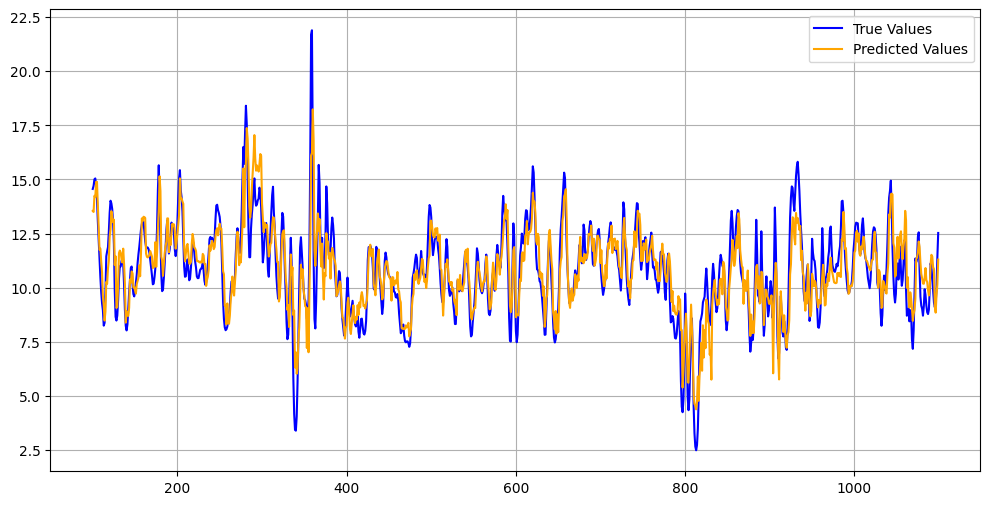

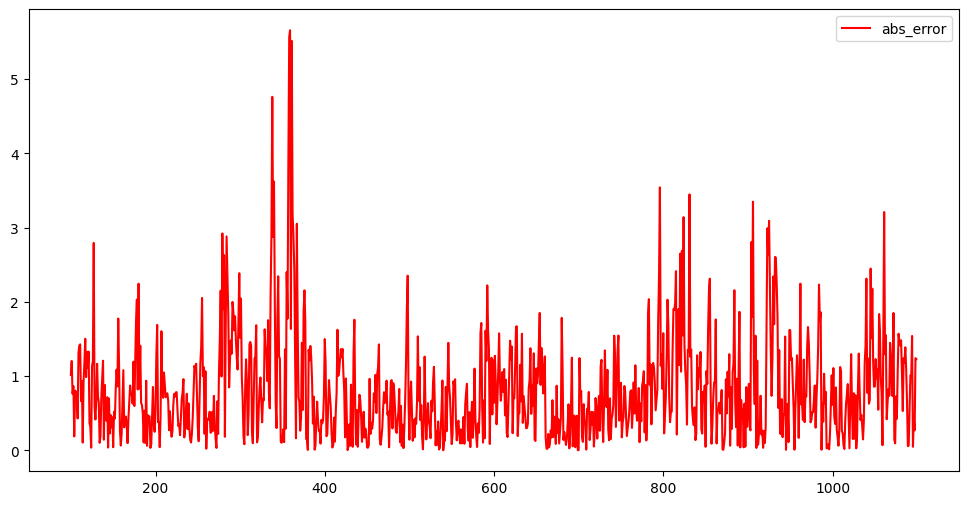

In [5]:
import matplotlib.pyplot as plt

# 畫圖
plt.figure(figsize=(12, 6))
plt.plot(result_df[y_col], label='True Values', color='blue')
plt.plot(result_df['prediction'], label='Predicted Values', color='orange')

plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(result_df['abs_error'], label='abs_error', color='red')#換個軸
plt.legend()
plt.show()


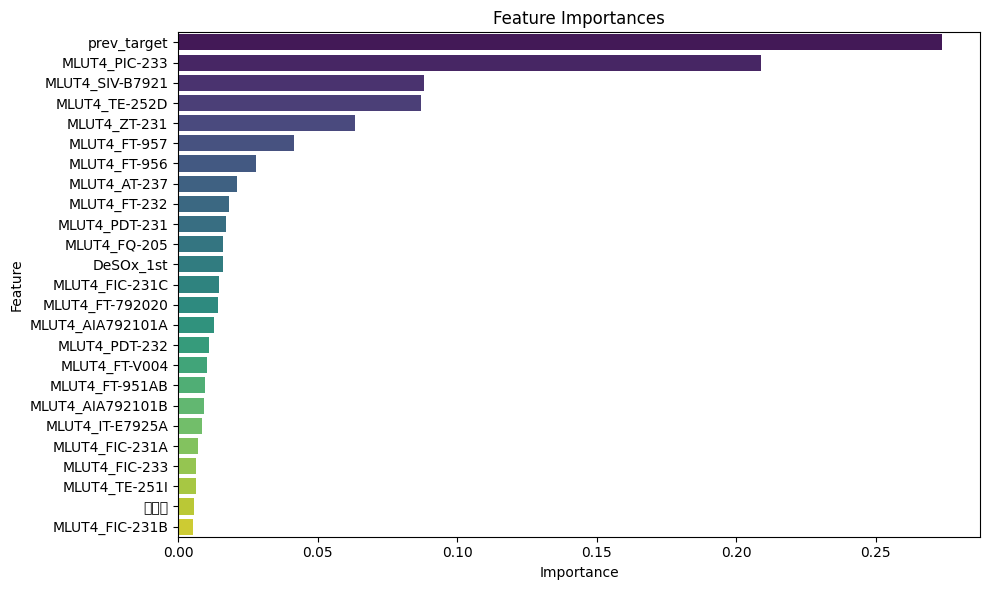

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 建立特徵重要度的 DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': train_X.columns,
    'Importance': current_model.feature_importances_
})

# 根據重要度排序
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 繪圖
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()


#比較濾波效果

In [7]:
import matplotlib.pyplot as plt

select_df = df.loc[~df.index.isin(common_index), :]
select_df = select_df[features+[y_col]]
select_df = select_df.sort_index().reset_index(drop=True)
select_df = select_df[select_df[y_col]>0]
origin = select_df[y_col]
after_filter = apply_kalman_filter(select_df[y_col])

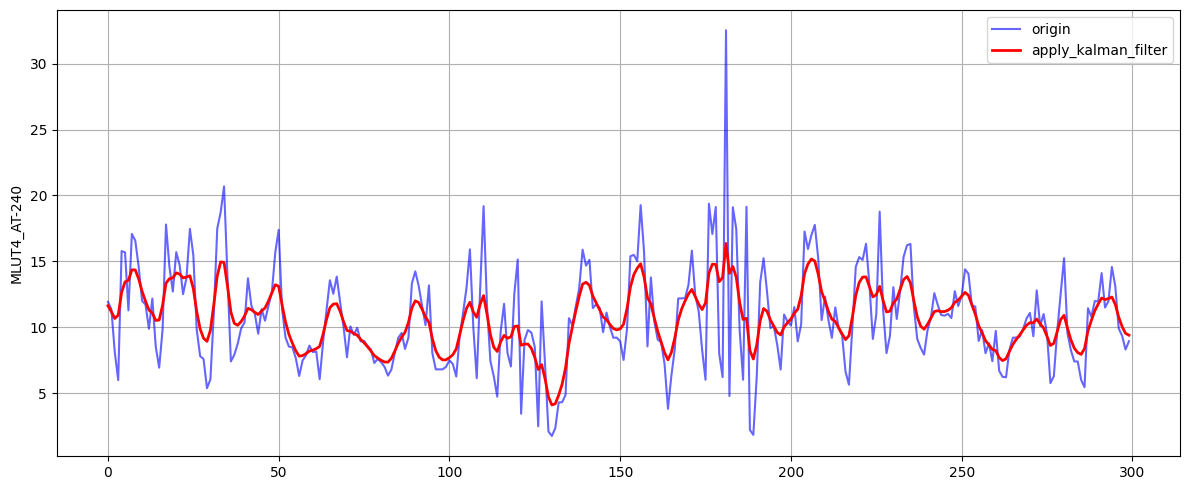

In [8]:
# 畫圖
plt.figure(figsize=(12, 5))
plt.plot(origin.values[-300:], label='origin', color='blue', alpha=0.6)
plt.plot(after_filter[-300:], label='apply_kalman_filter', color='red', linewidth=2)
plt.ylabel(y_col)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()